In [ ]:
# import the necessary packages
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import argparse
import cv2
import os
from keras.applications.resnet50 import ResNet50
from keras.preprocessing import image
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np


In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv2D, MaxPool2D, Flatten
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
!git clone https://github.com/vaibhavG321/Classification-of-COVID-19-chest-X-ray-images

Cloning into 'Classification-of-COVID-19-chest-X-ray-images'...
remote: Enumerating objects: 901, done.
remote: Counting objects: 100% (245/245), done.
remote: Compressing objects: 100% (166/166), done.
remote: Total 901 (delta 58), reused 224 (delta 48), pack-reused 656 (from 1)
Receiving objects: 100% (901/901), 235.19 MiB | 12.63 MiB/s, done.
Resolving deltas: 100% (86/86), done.
Updating files: 100% (807/807), done.


In [ ]:
!ls

Classification-of-COVID-19-chest-X-ray-images  sample_data


In [ ]:
cd Classification-of-COVID-19-chest-X-ray-images

/content/Classification-of-COVID-19-chest-X-ray-images


In [ ]:
!ls

 aditi-godbole-model.py		    covid19_project_pruning.ipynb
 aditi-verma-model.py		    covid_VGG16.ipynb
 aditya-babar-model.py		    dataset
 aditya-gurnani-model.py	   'ionic application'
 augmentation.ipynb		    README.md
 covid19_internship_project.ipynb   test1.ipynb
 covid19_project.ipynb		    vaibhav-model.py


In [ ]:
cd dataset

/content/Classification-of-COVID-19-chest-X-ray-images/dataset


In [ ]:
!ls

evaluation  testing  training


In [ ]:
cd training

/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training


In [ ]:
!ls

infected  normal


In [ ]:
train_normal_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/normal'
train_infected_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected'
test_normal_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/normal'
test_infected_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/infected'
evaluate_normal_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/normal'
evaluate_infected_path='/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/infected'

In [ ]:
print('train_normal cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/normal')))
print('train_infected cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected')))
print('test_normal cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/normal')))
print('test_infected cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/testing/infected')))
print('evaluate_normal cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/normal')))
print('evaluate_infected cases ',len(os.listdir('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/evaluation/infected')))

train_normal cases  297
train_infected cases  296
test_normal cases  69
test_infected cases  25
evaluate_normal cases  1
evaluate_infected cases  1


In [ ]:
IMAGE_SIZE = (224,224)
DIR_NAME = '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/'
IMAGE_DIR = DIR_NAME + 'normal/'
imagePaths=[]
for dirname, _, filenames in os.walk(DIR_NAME):
    for filename in filenames:
      imagePaths.append(os.path.join(dirname, filename))

In [ ]:
imagePaths

['/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (15).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (57).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (11).jpeg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (14).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (106).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (43).jpeg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (25).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (32).jpg',
 '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train24.jpeg',
 '/content/Classification-of-COVID-19-chest-X

In [ ]:
data = []
labels = []
# loop over the image paths
for imagePath in imagePaths:
	# extract the class label from the filename
	label = imagePath.split(os.path.sep)[-2]
	# load the image, swap color channels, and resize it to be a fixed
	# 224x224 pixels while ignoring aspect ratio
	image = cv2.imread(imagePath)
	image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
	image = cv2.resize(image, (224, 224))
	# update the data and labels lists, respectively
	data.append(image)
	labels.append(label)
# convert the data and labels to NumPy arrays while scaling the pixel
# intensities to the range [0, 1]
data = np.array(data) / 255.0
labels = np.array(labels)

In [ ]:
data.shape

(689, 224, 224, 3)

In [ ]:
labels


array(['infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infected',
       'infected', 'infected', 'infected', 'infected', 'infect

In [ ]:
# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)
# partition the data into training and testing splits using 80% of
# the data for training and the remaining 20% for testing
(trainX, testX, trainY, testY) = train_test_split(data, labels,
	test_size=0.20, stratify=labels, random_state=42)
# initialize the training data augmentation object
trainAug = ImageDataGenerator(shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,	rotation_range=15,
	fill_mode="nearest")

In [ ]:
trainAug

In [ ]:
trainX.shape,testX.shape,trainY.shape,testY.shape

((551, 224, 224, 3), (138, 224, 224, 3), (551, 2), (138, 2))

USING VGG16 MODEL

In [ ]:
baseModel = VGG16(weights="imagenet", include_top=False,
	input_tensor=Input(shape=(224, 224, 3)))
# construct the head of the model that will be placed on top of the
# the base model
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)
# place the head FC model on top of the base model (this will become
# the actual model we will train)
model = Model(inputs=baseModel.input, outputs=headModel)
# loop over all layers in the base model and freeze them so they will
# *not* be updated during the first training process
for layer in baseModel.layers:
	layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)


In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 0.001
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.5571 - loss: 0.7067

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 299ms/step - accuracy: 0.6446 - loss: 0.6518 - val_accuracy: 0.9348 - val_loss: 0.5292
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7500 - loss: 0.5107

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7500 - loss: 0.5107 - val_accuracy: 0.9203 - val_loss: 0.5264
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8218 - loss: 0.5366

68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.8287 - loss: 0.4966 - val_accuracy: 0.9420 - val_loss: 0.3642
Epoch 4/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8750 - loss: 0.3764

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8750 - loss: 0.3764 - val_accuracy: 0.9420 - val_loss: 0.3617
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8813 - loss: 0.4116

68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.8766 - loss: 0.3913 - val_accuracy: 0.9420 - val_loss: 0.2614
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7500 - loss: 0.5526 - val_accuracy: 0.9420 - val_loss: 0.2612
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8765 - loss: 0.3267

68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.8785 - loss: 0.3231 - val_accuracy: 0.9493 - val_loss: 0.2096
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8750 - loss: 0.3337 - val_accuracy: 0.9493 - val_loss: 0.2086
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9178 - loss: 0.2691

68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.9024 - loss: 0.2803 - val_accuracy: 0.9493 - val_loss: 0.1823
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8750 - loss: 0.3399 - val_accuracy: 0.9493 - val_loss: 0.1782
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.8932 - loss: 0.2680 - val_accuracy: 0.9493 - val_loss: 0.1616
Epoch 12/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 1.0000 - loss: 0.1292

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.1292 - val_accuracy: 0.9493 - val_loss: 0.1621
Epoch 13/25
66/68 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9371 - loss: 0.2059

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step
              precision    recall  f1-score   support

    infected       1.00      0.94      0.97        64
      normal       0.95      1.00      0.97        74

    accuracy                           0.97       138
   macro avg       0.97      0.97      0.97       138
weighted avg       0.97      0.97      0.97       138



In [ ]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


[[60  4]
 [ 0 74]]
acc: 0.9710
sensitivity: 0.9375
specificity: 1.0000


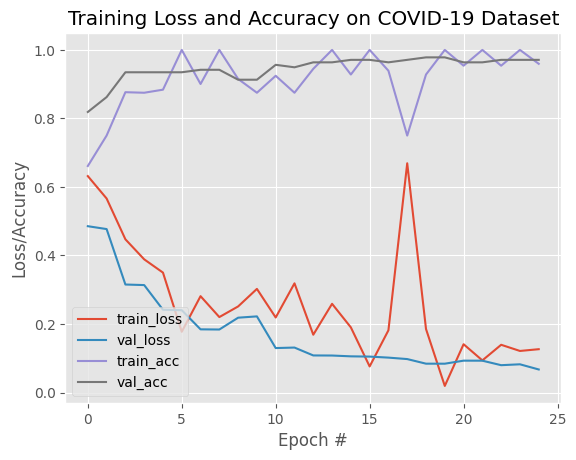

In [ ]:
# plot the training loss and accuracy
N = EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

In [ ]:
predIdxs

array([0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


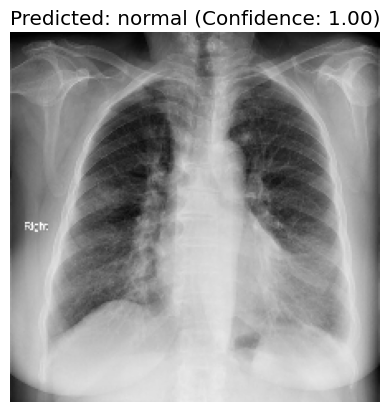

In [ ]:
#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image_path = '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (1).jpeg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
resized_image = cv2.resize(image, (224, 224))
img=np.reshape(resized_image,(1,224,224,3))

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

Displaying predictions for 4 images:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


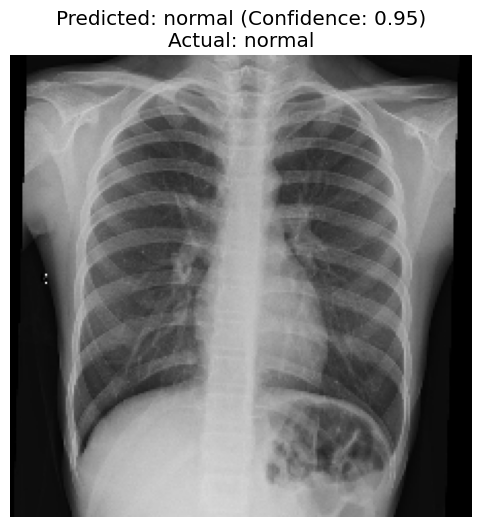

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


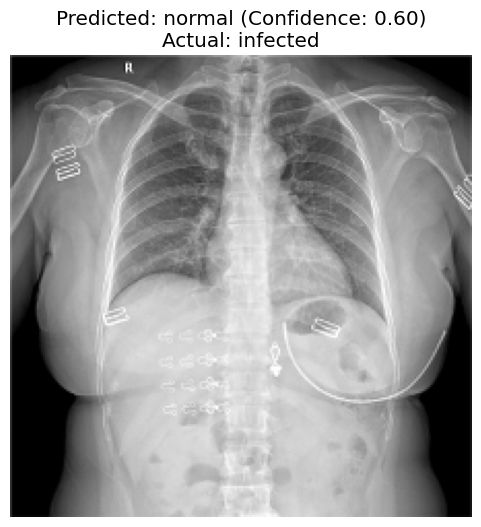

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


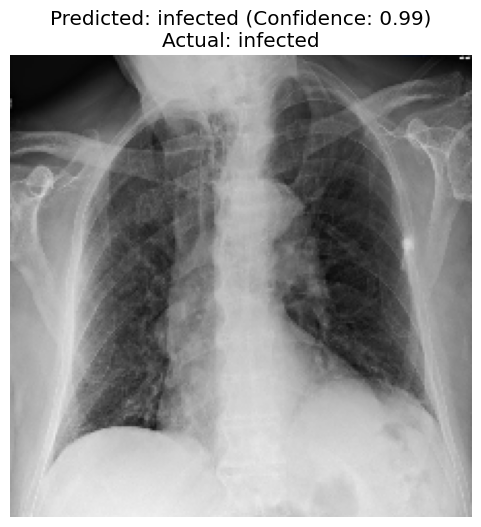

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


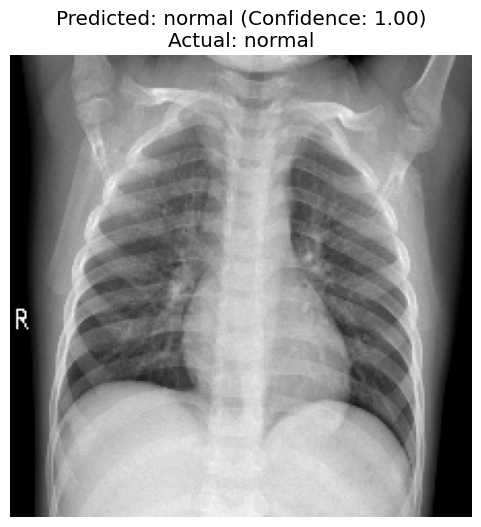

In [ ]:
# Select a few images for visualization (e.g., 2 infected, 2 normal)
num_images_to_display = 4

# Get image paths for infected and normal cases
infected_image_paths = [p for p in imagePaths if 'infected' in p]
normal_image_paths = [p for p in imagePaths if 'normal' in p]

# Randomly select a few images from each class
selected_infected_paths = np.random.choice(infected_image_paths, num_images_to_display // 2, replace=False)
selected_normal_paths = np.random.choice(normal_image_paths, num_images_to_display // 2, replace=False)

# Combine and shuffle the selected paths
selected_image_paths = np.concatenate((selected_infected_paths, selected_normal_paths))
np.random.shuffle(selected_image_paths)

print(f"Displaying predictions for {len(selected_image_paths)} images:")

# Loop through selected image paths and display predictions
for img_path in selected_image_paths:
    image = cv2.imread(img_path)
    if image is None:
        print(f"Warning: Could not load image at {img_path}. Skipping.")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    resized_image = cv2.resize(image, (224, 224))
    img_for_prediction = np.reshape(resized_image, (1, 224, 224, 3)) / 255.0 # Scale for model input

    # Make prediction
    prediction = model.predict(img_for_prediction)
    predicted_class_idx = np.argmax(prediction)
    predicted_label = lb.classes_[predicted_class_idx]

    # Display image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(resized_image)
    plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})\nActual: {img_path.split(os.path.sep)[-2]}")
    plt.axis('off')
    plt.show()

In [ ]:
img.shape

(1, 224, 224, 3)

END OF VGG16


WITHOUT PRETRAINED MODEL

In [ ]:
model = Sequential()
model.add(Conv2D(80, (3, 3),activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(32, (3, 3),activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.5))
model.add(Conv2D(32, (3, 3),activation='relu'))


model.add(Conv2D(64, (3, 3),activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.5866 - loss: 0.6942

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.6943 - loss: 0.5694 - val_accuracy: 0.9710 - val_loss: 0.3589
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8750 - loss: 0.3261

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8750 - loss: 0.3261 - val_accuracy: 0.9565 - val_loss: 0.3069
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9033 - loss: 0.2563

68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.8877 - loss: 0.2843 - val_accuracy: 0.9710 - val_loss: 0.1578
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7500 - loss: 0.4080 - val_accuracy: 0.9710 - val_loss: 0.1745
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9029 - loss: 0.2318

68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.9098 - loss: 0.2200 - val_accuracy: 0.9710 - val_loss: 0.1385
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8750 - loss: 0.3797 - val_accuracy: 0.9710 - val_loss: 0.1469
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9539 - loss: 0.1631

68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.9484 - loss: 0.1735 - val_accuracy: 0.9710 - val_loss: 0.1544
Epoch 8/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 1.0000 - loss: 0.1942

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1942 - val_accuracy: 0.9783 - val_loss: 0.1356
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.9392 - loss: 0.1762 - val_accuracy: 0.9203 - val_loss: 0.2037
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0909 - val_accuracy: 0.8841 - val_loss: 0.2693
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.9429 - loss: 0.1412 - val_accuracy: 0.9565 - val_loss: 0.1336
Epoch 12/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9420 - val_loss: 0.1424
Epoch 13/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.9245 - loss: 0.1813 - val_accuracy: 0.8913 - val_loss: 0.3031
Epoch 14/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0634 - val_accuracy: 0.8696 - val_loss: 0.3546
Epoch 15/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - accuracy: 0.9411 - loss: 0.1833 - val_accuracy: 0.9638 - val_los

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step
              precision    recall  f1-score   support

    infected       0.92      0.95      0.94        64
      normal       0.96      0.93      0.95        74

    accuracy                           0.94       138
   macro avg       0.94      0.94      0.94       138
weighted avg       0.94      0.94      0.94       138



In [ ]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[61  3]
 [ 5 69]]
acc: 0.9420
sensitivity: 0.9531
specificity: 0.9324


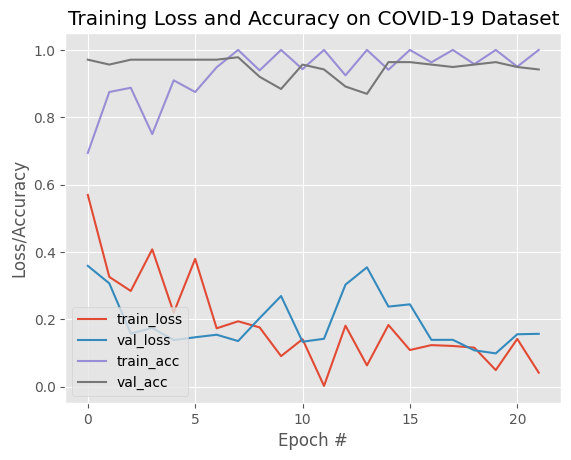

In [ ]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


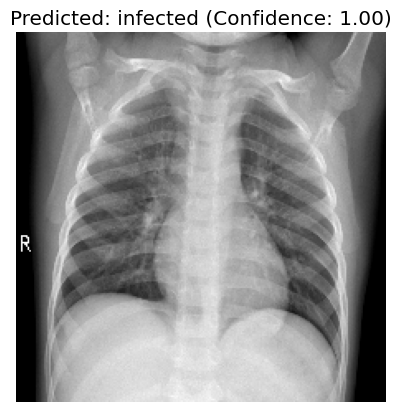

In [ ]:
#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF WITHOUT PRETRAINED MODEL

USING INCEPTION-V3 MODEL

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16,InceptionV3
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

In [ ]:
baseModel = InceptionV3(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))
#construct the head of the model that will be placed on top of the
#the base model

headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.7893 - loss: 0.5446

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 51s 502ms/step - accuracy: 0.8711 - loss: 0.3679 - val_accuracy: 0.9203 - val_loss: 0.1855
Epoch 2/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7500 - loss: 0.6010 - val_accuracy: 0.9203 - val_loss: 0.1801
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9218 - loss: 0.2269

68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.9300 - loss: 0.2035 - val_accuracy: 0.9638 - val_loss: 0.0903
Epoch 4/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 0.0583

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0583 - val_accuracy: 0.9638 - val_loss: 0.0862
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.9448 - loss: 0.1851 - val_accuracy: 0.9275 - val_loss: 0.1100
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0283 - val_accuracy: 0.9275 - val_loss: 0.1087
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.9576 - loss: 0.1370 - val_accuracy: 0.9710 - val_loss: 0.0618
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0534 - val_accuracy: 0.9710 - val_loss: 0.0621
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.9503 - loss: 0.1349 - val_accuracy: 0.9420 - val_loss: 0.1252
Epoch 10/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8750 - loss: 0.1964 - val_accuracy: 0.9348 - val_loss: 0.1454
Epoch 11/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - accuracy: 0.9521 - loss: 0.1249 - val_accuracy: 0.9855 - val_loss

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 509ms/step
              precision    recall  f1-score   support

    infected       0.94      1.00      0.97        64
      normal       1.00      0.95      0.97        74

    accuracy                           0.97       138
   macro avg       0.97      0.97      0.97       138
weighted avg       0.97      0.97      0.97       138



In [ ]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[64  0]
 [ 4 70]]
acc: 0.9710
sensitivity: 1.0000
specificity: 0.9459


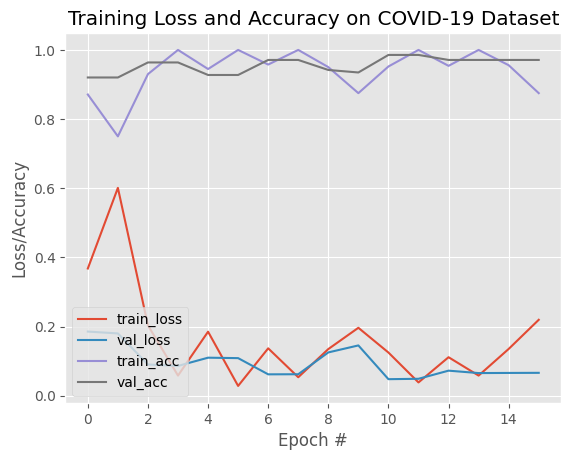

In [ ]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


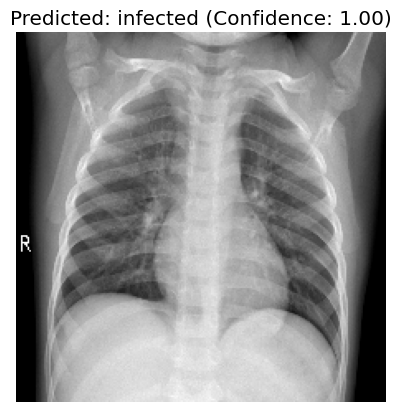

In [ ]:


#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF INCEPTION V3 MODEL

RESNET50

In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [ ]:
res = ResNet50(weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3)))
outputs = res.output
outputs = Flatten(name="flatten")(outputs)
outputs = Dropout(0.5)(outputs)
outputs = Dense(2, activation="softmax")(outputs)
model = Model(inputs=res.input, outputs=outputs)
for layer in res.layers:
  layer.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.5684 - loss: 1.4328

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 35s 335ms/step - accuracy: 0.6169 - loss: 1.0808 - val_accuracy: 0.8986 - val_loss: 0.2998
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 1.0000 - loss: 0.1724

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 1.0000 - loss: 0.1724 - val_accuracy: 0.8986 - val_loss: 0.2919
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.7993 - loss: 0.4950 - val_accuracy: 0.6594 - val_loss: 0.7005
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6250 - loss: 1.4219 - val_accuracy: 0.7174 - val_loss: 0.5612
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.8527 - loss: 0.4093 - val_accuracy: 0.9058 - val_loss: 0.2217
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7500 - loss: 0.5581 - val_accuracy: 0.9348 - val_loss: 0.1849
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.8564 - loss: 0.4318 - val_accuracy: 0.9638 - val_loss: 0.1032
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7500 - loss: 0.5526 - val_accuracy: 0.8696 - val_loss: 0.2656
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.8140 - loss: 0.5319 - val_accuracy: 0.9638 - val_loss: 0

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 307ms/step
              precision    recall  f1-score   support

    infected       0.93      1.00      0.96        64
      normal       1.00      0.93      0.97        74

    accuracy                           0.96       138
   macro avg       0.96      0.97      0.96       138
weighted avg       0.97      0.96      0.96       138



In [ ]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[64  0]
 [ 5 69]]
acc: 0.9638
sensitivity: 1.0000
specificity: 0.9324


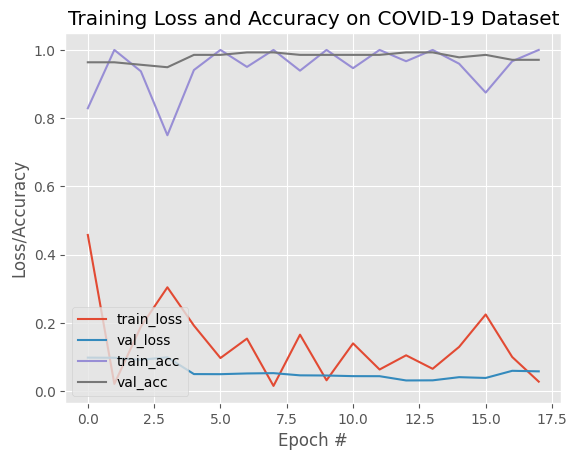

In [ ]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


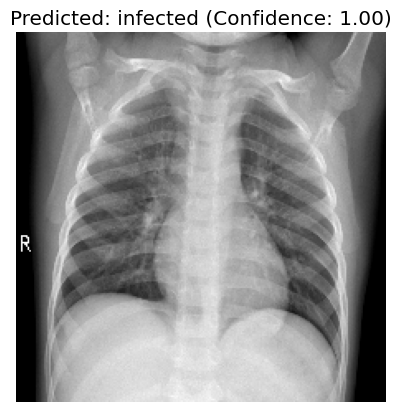

In [ ]:


#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF RESNET50


MOBILENET BY GOOGLE


In [ ]:
import tensorflow as tf

In [ ]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model MobileNet V2
baseModel = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7330 - loss: 0.6771

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 65s 632ms/step - accuracy: 0.8290 - loss: 0.4580 - val_accuracy: 0.9638 - val_loss: 0.0985
Epoch 2/25
 1/68 ━━━━━━━━━━━━━━━━━━━━ 14:24 13s/step - accuracy: 1.0000 - loss: 0.0215

68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 1.0000 - loss: 0.0215 - val_accuracy: 0.9638 - val_loss: 0.0981
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.9374 - loss: 0.1892 - val_accuracy: 0.9565 - val_loss: 0.0925
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7500 - loss: 0.3045 - val_accuracy: 0.9493 - val_loss: 0.0994
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - accuracy: 0.9411 - loss: 0.1924 - val_accuracy: 0.9855 - val_loss: 0.0503
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0973 - val_accuracy: 0.9855 - val_loss: 0.0500
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9503 - loss: 0.1543 - val_accuracy: 0.9928 - val_loss: 0.0521
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0156 - val_accuracy: 0.9928 - val_loss: 0.0531
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step - accuracy: 0.9392 - loss: 0.1658 - val_accuracy: 0.9855 - val_l

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 807ms/step
              precision    recall  f1-score   support

    infected       0.94      1.00      0.97        64
      normal       1.00      0.95      0.97        74

    accuracy                           0.97       138
   macro avg       0.97      0.97      0.97       138
weighted avg       0.97      0.97      0.97       138



In [ ]:
# compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))

[[64  0]
 [ 4 70]]
acc: 0.9710
sensitivity: 1.0000
specificity: 0.9459


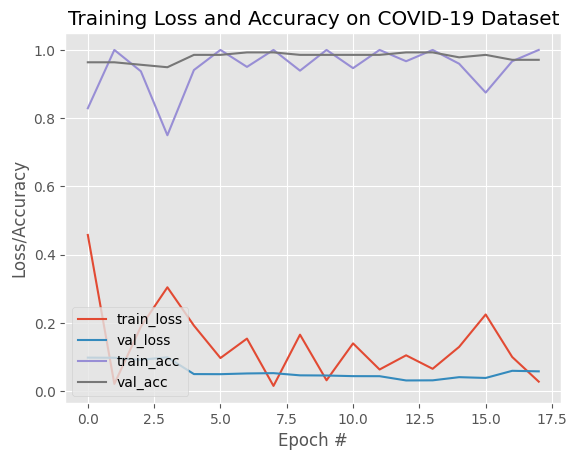

In [ ]:
# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


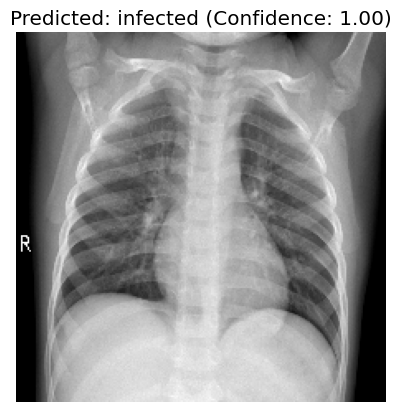

In [ ]:


#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF MOBILENET


NASNetlarge

In [ ]:
from tensorflow.keras.applications.nasnet import NASNetLarge


In [ ]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model MobileNet V2
baseModel = tf.keras.applications.NASNetLarge(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False


343610240/343610240 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.9061 - loss: 0.2563 - val_accuracy: 0.9493 - val_loss: 0.1738
Epoch 2/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 1.0000 - loss: 0.0850 - val_accuracy: 0.9493 - val_loss: 0.1705
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.9337 - loss: 0.1805 - val_accuracy: 0.9638 - val_loss: 0.1326
Epoch 4/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7500 - loss: 0.6625 - val_accuracy: 0.9710 - val_loss: 0.1345
Epoch 5/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - accuracy: 0.9484 - loss: 0.1485 - val_accuracy: 0.9710 - val_loss: 0.1684
Epoch 6/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 1.0000 - loss: 0.0615 - val_accuracy: 0.9710 - val_loss: 0.1699
Epoch 7/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.9595 - loss: 0.1298 - val_accuracy: 0.9348 - val_loss: 0.1824
Epoch 8/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 1.0000 - loss: 0.0277 - val_accuracy: 0.9203 - val_loss: 0.2000
Epoch 9/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.9558 - loss: 0.1323 - val_accuracy: 0.9710 - val_

[INFO] evaluating network...
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
              precision    recall  f1-score   support

    infected       0.94      1.00      0.97        64
      normal       1.00      0.95      0.97        74

    accuracy                           0.97       138
   macro avg       0.97      0.97      0.97       138
weighted avg       0.97      0.97      0.97       138

[[64  0]
 [ 4 70]]
acc: 0.9710
sensitivity: 1.0000
specificity: 0.9459


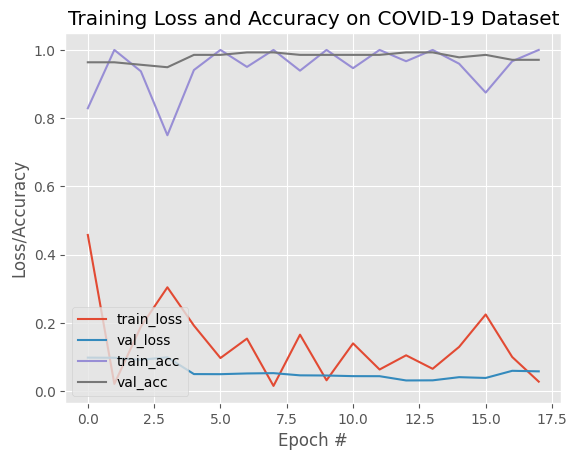

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 51s 51s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


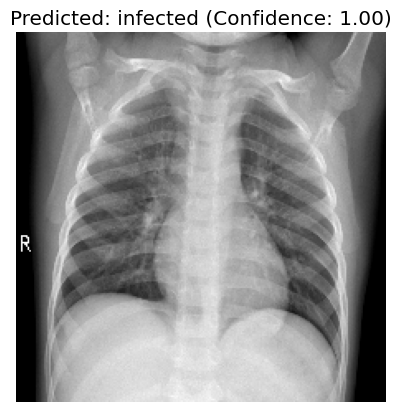

In [ ]:

#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

END OF NASNetLarge


Xception MODEL

### Re-initializing Data Augmentation and Splits

This cell re-defines the `trainAug` object and re-creates the training and testing data splits (`trainX`, `trainY`, `testX`, `testY`) and `LabelBinarizer` (`lb`). This is necessary to ensure these variables are available and correctly configured for the models that follow, especially after potential kernel restarts or out-of-order execution that might clear their definitions.

In [ ]:
import os
import numpy as np
import cv2 # Assuming cv2 is needed for image processing based on earlier cells
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Re-define DIR_NAME and collect image paths
DIR_NAME = '/content/Classification-of-COVID-19-chest-X-ray-images/dataset/'
imagePaths=[]
for dirname, _, filenames in os.walk(DIR_NAME):
    for filename in filenames:
      imagePaths.append(os.path.join(dirname, filename))

# Load and preprocess images, create data and labels arrays
data = []
labels = []
# loop over the image paths
for imagePath in imagePaths:
	# extract the class label from the filename
	label = imagePath.split(os.path.sep)[-2]
	# load the image, swap color channels, and resize it to be a fixed
	# 224x224 pixels while ignoring aspect ratio
	image = cv2.imread(imagePath)
	if image is None: # Added error handling for images that might fail to load
        print(f"Warning: Could not load image at {imagePath}. Skipping.")
        continue
	image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
	image = cv2.resize(image, (224, 224))
	# update the data and labels lists, respectively
	data.append(image)
	labels.append(label)
# convert the data and labels to NumPy arrays while scaling the pixel
# intensities to the range [0, 1]
data = np.array(data) / 255.0
labels = np.array(labels)

# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)
# partition the data into training and testing splits using 80% of
# the data for training and the remaining 20% for testing
(trainX, testX, trainY, testY) = train_test_split(data, labels,
	test_size=0.20, stratify=labels, random_state=42)
# initialize the training data augmentation object
trainAug = ImageDataGenerator(shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,	rotation_range=15,
	fill_mode="nearest")

TabError: inconsistent use of tabs and spaces in indentation (2837823851.py, line 27)

In [ ]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.preprocessing import image
#from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

In [ ]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model Xception
baseModel = tf.keras.applications.Xception(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


Xception_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

In [ ]:


model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
Xception_model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = Xception_model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

[INFO] compiling model...
[INFO] training head...


NameError: name 'trainAug' is not defined

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = Xception_model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

[INFO] evaluating network...


NameError: name 'Xception_model' is not defined

In [ ]:

#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
model.predict(img)

# Make prediction
prediction = model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

NameError: name 'cv2' is not defined

END OF XCEPTION

DENSENET121

In [ ]:
from tensorflow.keras.applications import DenseNet121


In [ ]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model MobileNet V2
baseModel = tf.keras.applications.DenseNet121(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


DenseNet121_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model DenseNet121
baseModel = tf.keras.applications.DenseNet121(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


DenseNet121_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)

# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
DenseNet121_model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = DenseNet121_model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[INFO] compiling model...
[INFO] training head...
Epoch 1/25
59/68 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6335 - loss: 0.8556

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = DenseNet121_model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

[INFO] evaluating network...


NameError: name 'DenseNet121_model' is not defined

In [ ]:
#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
DenseNet121_model.predict(img)

# Make prediction
prediction = DenseNet121_model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

NameError: name 'DenseNet121_model' is not defined

END OF DENSE121


INCEPTION RESNETV2

In [ ]:
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2, preprocess_input

In [ ]:
IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model Xception
baseModel = InceptionResNetV2(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


InceptionResNetV2_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

IMG_SHAPE = (224,224,3)

# Create the base model from the pre-trained model InceptionResNetV2
baseModel = InceptionResNetV2(include_top=False,weights='imagenet',input_tensor=Input(shape=(224, 224, 3)))
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(4, 4))(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(64, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)


InceptionResNetV2_model= Model(inputs=baseModel.input, outputs=headModel)

for layer in baseModel.layers:
    layer.trainable = False

model_chkpt = ModelCheckpoint('best_mod.h5', save_best_only=True, monitor='accuracy')
early_stopping = EarlyStopping(monitor='loss', restore_best_weights=False, patience=10)
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-3
EPOCHS = 25
BS = 8
# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR)
InceptionResNetV2_model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])
# train the head of the network
print("[INFO] training head...")
H = InceptionResNetV2_model.fit(
	trainAug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS,callbacks=[early_stopping,model_chkpt])

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[INFO] compiling model...
[INFO] training head...


NameError: name 'trainAug' is not defined

In [ ]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = InceptionResNetV2_model.predict(testX, batch_size=BS)
# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)
# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))



  # compute the confusion matrix and and use it to derive the raw
# accuracy, sensitivity, and specificity
cm = confusion_matrix(testY.argmax(axis=1), predIdxs)
total = sum(sum(cm))
acc = (cm[0, 0] + cm[1, 1]) / total
sensitivity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
specificity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
# show the confusion matrix, accuracy, sensitivity, and specificity
print(cm)
print("acc: {:.4f}".format(acc))
print("sensitivity: {:.4f}".format(sensitivity))
print("specificity: {:.4f}".format(specificity))


# plot the training loss and accuracy
N = len(H.history["loss"])
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy on COVID-19 Dataset")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
#plt.savefig(args["plot"])

[INFO] evaluating network...


NameError: name 'InceptionResNetV2_model' is not defined

In [ ]:
#from IPython.display import Image
#Image('/content/drive/My Drive/covid dataset/images/1-s2.0-S0929664620300449-gr2_lrg-a.jpg')
image = cv2.imread('/content/Classification-of-COVID-19-chest-X-ray-images/dataset/training/infected/covid_train (10).jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (224, 224))
img=np.reshape(image,(1,224,224,3))
InceptionResNetV2_model.predict(img)

# Make prediction
prediction = InceptionResNetV2_model.predict(img)
predicted_class_idx = np.argmax(prediction)
predicted_label = lb.classes_[predicted_class_idx]

# Display image and prediction
plt.imshow(resized_image)
plt.title(f"Predicted: {predicted_label} (Confidence: {prediction[0][predicted_class_idx]:.2f})")
plt.axis('off')
plt.show()

NameError: name 'InceptionResNetV2_model' is not defined

END OF INCEPTION RESNETV2